### 오차 역전파
- 순전파 : 입력 데이터를 입력층에서 출력층까지 정방향으로 이동시켜서 출력값을 예측하는 과정
  - 예측하는 과정
- 역전파 : 출력층에서 발생한 에러를 입력층으로 전파시키면서 최적의 결과를 학습해 나가는 과정
  - 최적의 방향으로 학습하는 과정

- batch_size : 한번의 epoch로는 모든 데이터를 학습하기 어렵기 때문에 나눠서 학습하는 방법
  - batch_size가 작을수록 메모리 소모는 작음, 학습속도는 느린대신 정확도는 올라갈 수 있음
  - batch_size가 클수록 모모리 소모는 큼, 학습속도는 빠르나 정확도는 줄어들 수 있음

### 최적화 함수 종류(Optimizer)
- SGD(확률적 경사 하강법)
  - 오차를 줄여나갈 수 있도록 확률적으로 선택된 일부 데이터를 업데이트하여 학습하는 방법
- 모멘텀(Momentum)
  - 경사하강법에서 가중치를 수정할 때 이전 방향을 참고하여 업데이트 하는 방법
  - 지그재그현상을 줄일 수 있음
  - 학습속도가 가속화 될 가능성이 있음
- Adagrad
  - 학습을 진행함에 있어 학습률을 점차 줄여나가는 방법
  - 처음에는 학습률을 크게 학습하여 가중치 변동을 크게 진행하고 점점 작게 학습하여 오차에 대해 최적의 해를 찾아 나가는 방법
  - 학습속도가 빠르고 정확하다는 장점이 있음
- Adam
  - 학습에 대해서 학습률을 점차 줄여나가면서 방향 또한 이전 방향을 참고하여 최적의 해를 찾아 나가는 방법
  - 현재 가장 많이 사용하는 방법(장점만을 모았음)

### 오늘의 목표
- 패션데이터를 가지고 활성화 함수, 최적화 함수를 변화시키면서 결과를 확인해보는 실습을 진행하기

In [ ]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 작업 디렉토리 변경
%cd /content/drive/MyDrive/Colab Notebooks/딥러닝

/content/drive/MyDrive/Colab Notebooks/딥러닝


In [ ]:
# 현재 작업디렉토리 확인
!pwd

/content/drive/MyDrive/Colab Notebooks/딥러닝


In [ ]:
# 데이터 다루기 위해 불러오는 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 데이터 가져오기
# sklearn에서 데이터를 제공했듯이 tensorflow에서도 데이터셋을 제공해준다.
# tensorflow에 있는 패션데이터를 불러와보기
from tensorflow.keras.datasets import fashion_mnist

In [ ]:
# 데이터 로드
data = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
data

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [ ]:
from re import X
# 데이터 분할 (X_train, X_test, y_train, y_test)
X_train = data[0][0]
y_train = data[0][1]
X_test = data[1][0]
y_test = data[1][1]

In [ ]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

In [ ]:
# 정답 데이터 확인
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

### 정답데이터 분류
- 0 : 티셔츠
- 1 : 트라우저(바지)
- 2 : 단추가 없는 스웨터
- 3 : 드레스
- 4 : 코트
- 5 : 샌들
- 6 : 셔츠
- 7 : 스니커즈
- 8 : 가방
- 9 : 앵클 부츠

### 신경망 구축
- 데이터 전치리 진행
- MLP 구성

### 이미지 데이터
- 이미지는 2차원(흑백) 또는 3차원(컬러) 형태를 가진다.
- MLP는 1차원 데이터만 학습이 가능하다.
- 이미지 데이터의 차원을 1차원으로 변경해야만 학습이 가능
- reshape : 데이터의 형태를 변형할 수 있는 기능

### 이미지 전처리 진행
- MLP를 사용하기 위해 이미지의 차원을 1차원으로 변경(reshape 사용)

In [ ]:
# (28, 28) --> 1차원(784) 변형 진행
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [ ]:
# 데이터 변형하기
X_train_rs = X_train.reshape(60000, 784)
# X_train.reshape(60000, -1)
X_test_rs = X_test.reshape(10000, 784)
# X_test.reshape(60000, -1)

In [ ]:
# 크기 확인
print(X_train_rs.shape)
print(X_test_rs.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 784)
(10000, 784)
(60000,)
(10000,)


### 정답데이터 변경
- softmax(다중분류)를 사용하기 위해서는 정답데이터를 원핫인코딩을 해야만 사용할 수 있다.
- 다라서 y_train, y_test를 원핫인코딩 진행하기

In [ ]:
# 원핫인코딩 진행
y_train_one_hot = pd.get_dummies(y_train)
y_test_one_hot = pd.get_dummies(y_test)

### 신경망 설계 (MLP)
- 활성화 함수와 최적화 함수를 설정하여 성능비교 진행

# 1. 활성화 함수 : sigmoid / 최적화 함수 : SGD

In [ ]:
# 모델을 사용하기 위한 도구 불러오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.optimizers import SGD, Adam

In [ ]:
# 신경망 설계
model1 = Sequential()

# 입력층
model1.add(InputLayer(input_shape=(784,)))
# InputLayer는 입력층을 받기 위한 층이기 때문에 MLP에 전달할 때 원하는 크기로 받을 수 있음
# 우리가 사용할 때 shape(28, 28)로 사용이 가능하다
# 대신 Flatten층을 추가
# Flatten : 입력받은 층으로부터 데이터를 1차원으로 변경해서 사용하는 기능

# 중간층
model1.add(Dense(units=100, activation='sigmoid'))
model1.add(Dense(units=200, activation='sigmoid'))
model1.add(Dense(units=100, activation='sigmoid'))

# 출력층
model1.add(Dense(units=10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
# 학습방법 및 평가방법 설정
model1.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(),
    metrics=['accuracy']
)

In [ ]:
model1.fit(
    X_train_rs,
    y_train_one_hot,
    validation_split=0.2, # 검증 데이터 비율
    epochs=10, # 학습횟수
    batch_size=64 # 배치사이즈 설정
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3435 - loss: 2.2282 - val_accuracy: 0.5347 - val_loss: 2.1366
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5362 - loss: 1.9788 - val_accuracy: 0.5520 - val_loss: 1.7827
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5806 - loss: 1.5975 - val_accuracy: 0.6192 - val_loss: 1.4372
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6109 - loss: 1.3242 - val_accuracy: 0.6518 - val_loss: 1.2178
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6407 - loss: 1.1459 - val_accuracy: 0.6380 - val_loss: 1.0707
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6711 - loss: 1.0179 - val_accuracy: 0.7055 - val_loss: 0.9608
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7053 - loss: 0.9186 - val_accuracy: 0.7267 - val_loss: 0.8766
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7248 - loss: 0.8446 - val_accuracy: 0.

In [ ]:
# 최적화 함수 사용 방법
# optimizer = SGD()
# 학습률 조정을 하고싶을 경우
# SGD(learning_rate = 0.01) -> 0.01 or 0.001 많이 사용 (모델마다 다름)
# 모멘텀 방법으로 학습을 진행하고 싶은 경우
# SGD(learning_rate = 0.01, momentum = 0.9) # 모멘텀 지수는 일반적으로 0.9를 사용

### activation = sigmoid / optimizer = 모멘텀 사용

In [ ]:
# 신경망 설계
print(X_train.shape)
print(X_train_rs.shape)

(60000, 28, 28)
(60000, 784)


In [ ]:
# 만약에 이미지 데이터를 사용할 때 1차원으로 변경을 하지 못하고 사용할 경우
# Flatten를 이용하여 1차원으로 전달하는 방법이 존재
from tensorflow.keras.layers import Flatten

In [ ]:
# 뼈대 생성
model2 = Sequential()

# 입력층
model2.add(Flatten(input_shape=(28,28)))
# Flatten을 이용하여 1차원으로 변경하여  다음층으로 데이터를 전달

# 중간층
model2.add(Dense(100, activation='sigmoid'))
model2.add(Dense(200, activation='sigmoid'))
model2.add(Dense(100, activation='sigmoid'))

# 출력층
model2.add(Dense(10, activation='softmax'))

In [ ]:
# 학습방법 및 평가방법 설정 (모멘텀 사용)
model2.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    metrics=['accuracy']
)

In [ ]:
# 학습
model2.fit(
    X_train,
    y_train_one_hot,
    validation_split=0.2, # 검증 데이터 비율
    epochs=10, # 학습횟수
    batch_size=64 # 배치사이즈 설정
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5050 - loss: 1.4746 - val_accuracy: 0.6518 - val_loss: 1.0307
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6413 - loss: 1.0182 - val_accuracy: 0.5761 - val_loss: 1.1064
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5784 - loss: 1.1017 - val_accuracy: 0.5458 - val_loss: 1.1665
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5343 - loss: 1.1747 - val_accuracy: 0.5307 - val_loss: 1.1376
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4598 - loss: 1.3022 - val_accuracy: 0.3097 - val_loss: 1.4704
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4154 - loss: 1.3724 - val_accuracy: 0.4770 - val_loss: 1.3598
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4681 - loss: 1.2728 - val_accuracy: 0.6167 - val_loss: 1.0681
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5342 - loss: 1.1424 - val_accuracy: 0.

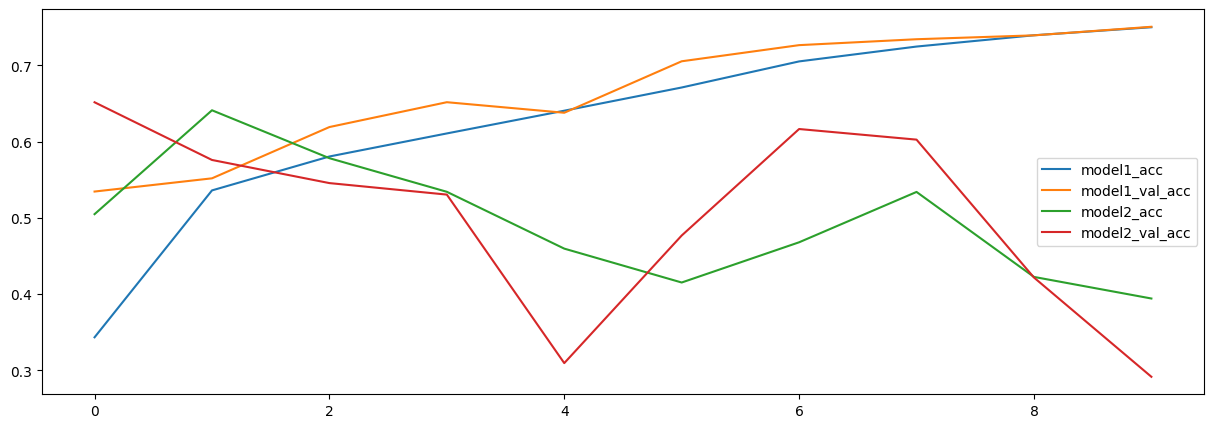

In [ ]:
# 2가지모델 결과 비교
plt.figure(figsize=(15,5))

# 1번모델(sigmoid+SGD)
plt.plot(model1.history.history['accuracy'], label='model1_acc')
plt.plot(model1.history.history['val_accuracy'], label='model1_val_acc')

# 2번모델(sigmoid+모멘텀)
plt.plot(model2.history.history['accuracy'], label='model2_acc')
plt.plot(model2.history.history['val_accuracy'], label='model2_val_acc')

plt.legend()
plt.show()

### 실습
3. 모델 : activation : sigmoid / optimizer : Adam
4. 모델 : activation : Relu / optimaizer : SGD
5. 모델 : activation : Relu / optimizer : Adam

In [ ]:
# 신경망 설계
model3 = Sequential()

# 입력층
model3.add(InputLayer(input_shape=(784,)))

# 중간층
model3.add(Dense(units=100, activation='sigmoid'))
model3.add(Dense(units=200, activation='sigmoid'))
model3.add(Dense(units=100, activation='sigmoid'))

# 출력층
model3.add(Dense(units=10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
# 학습방법 및 평가방법 설정
model3.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.01),
    metrics=['accuracy']
)

In [ ]:
model3.fit(
    X_train_rs,
    y_train_one_hot,
    validation_split=0.2, # 검증 데이터 비율
    epochs=10, # 학습횟수
    batch_size=64 # 배치사이즈 설정
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3245 - loss: 1.5525 - val_accuracy: 0.3462 - val_loss: 1.4997
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3022 - loss: 1.5806 - val_accuracy: 0.3511 - val_loss: 1.3997
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3701 - loss: 1.4452 - val_accuracy: 0.4170 - val_loss: 1.3139
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3661 - loss: 1.4094 - val_accuracy: 0.3781 - val_loss: 1.3892
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3708 - loss: 1.3810 - val_accuracy: 0.3537 - val_loss: 1.3897
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4323 - loss: 1.3280 - val_accuracy: 0.3842 - val_loss: 1.4494
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3811 - loss: 1.4135 - val_accuracy: 0.3650 - val_loss: 1.4888
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3375 - loss: 1.4882 - val_accuracy: 0.

In [ ]:
# 신경망 설계
model4 = Sequential()

# 입력층
model4.add(InputLayer(input_shape=(784,)))

# 중간층
model4.add(Dense(units=100, activation='relu'))
model4.add(Dense(units=200, activation='relu'))
model4.add(Dense(units=100, activation='relu'))

# 출력층
model4.add(Dense(units=10, activation='softmax'))

In [ ]:
# 학습방법 및 평가방법 설정
model4.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

In [ ]:
model4.fit(
    X_train_rs,
    y_train_one_hot,
    validation_split=0.2, # 검증 데이터 비율
    epochs=10, # 학습횟수
    batch_size=64 # 배치사이즈 설정
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0993 - loss: 2.3028 - val_accuracy: 0.1005 - val_loss: 2.3027
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0996 - loss: 2.3027 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1003 - loss: 2.3026 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0986 - loss: 2.3026 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1009 - loss: 2.3026 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1010 - loss: 2.3026 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0991 - loss: 2.3026 - val_accuracy: 0.0957 - val_loss: 2.3027
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0996 - loss: 2.3026 - val_accuracy: 0.

In [ ]:
# 신경망 설계
model5 = Sequential()

# 입력층
model5.add(InputLayer(input_shape=(784,)))

# 중간층
model5.add(Dense(units=100, activation='relu'))
model5.add(Dense(units=200, activation='relu'))
model5.add(Dense(units=100, activation='relu'))

# 출력층
model5.add(Dense(units=10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [75]:
# 학습방법 및 평가방법 설정
model5.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [76]:
model5.fit(
    X_train_rs,
    y_train_one_hot,
    validation_split=0.2, # 검증 데이터 비율
    epochs=10, # 학습횟수
    batch_size=64 # 배치사이즈 설정
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1078 - loss: 2.2905 - val_accuracy: 0.1109 - val_loss: 2.2799
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1265 - loss: 2.2301 - val_accuracy: 0.1710 - val_loss: 2.0864
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1852 - loss: 2.0607 - val_accuracy: 0.1867 - val_loss: 2.0205
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1937 - loss: 2.0099 - val_accuracy: 0.1928 - val_loss: 1.9887
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1938 - loss: 1.9910 - val_accuracy: 0.1949 - val_loss: 1.9637
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1982 - loss: 1.9387 - val_accuracy: 0.1968 - val_loss: 1.9050
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1982 - loss: 1.8977 - val_accuracy: 0.1998 - val_loss: 1.8280
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1960 - loss: 1.7556 - val_accuracy: 0.

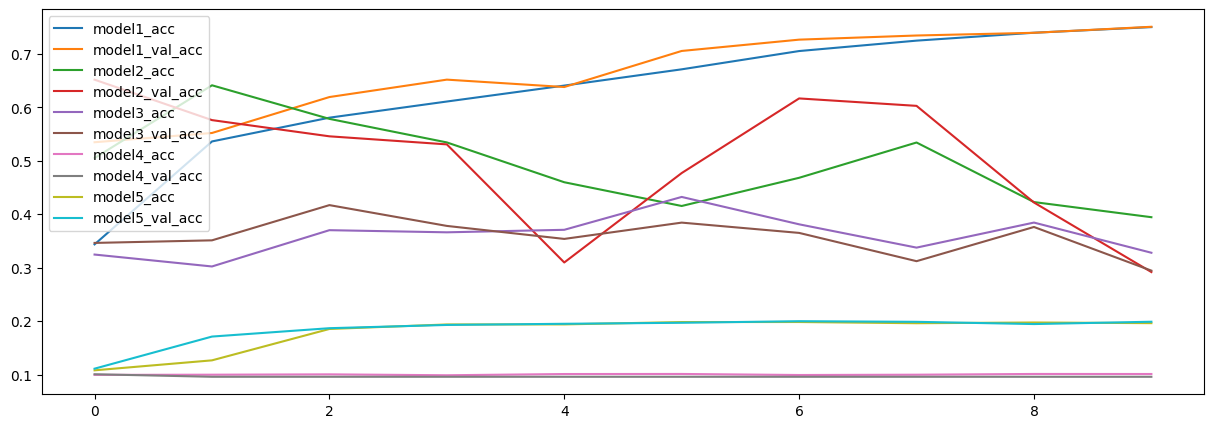

In [77]:
# 5가지모델 결과 비교
plt.figure(figsize=(15,5))

# 1번모델(sigmoid+SGD)
plt.plot(model1.history.history['accuracy'], label='model1_acc')
plt.plot(model1.history.history['val_accuracy'], label='model1_val_acc')

# 2번모델(sigmoid+모멘텀)
plt.plot(model2.history.history['accuracy'], label='model2_acc')
plt.plot(model2.history.history['val_accuracy'], label='model2_val_acc')

# 3번모델(sigmoid+Adam)
plt.plot(model3.history.history['accuracy'], label='model3_acc')
plt.plot(model3.history.history['val_accuracy'], label='model3_val_acc')

# 4번모델(relu+SGD)
plt.plot(model4.history.history['accuracy'], label='model4_acc')
plt.plot(model4.history.history['val_accuracy'], label='model4_val_acc')

# 5번모델(relu+Adam)
plt.plot(model5.history.history['accuracy'], label='model5_acc')
plt.plot(model5.history.history['val_accuracy'], label='model5_val_acc')

plt.legend()
plt.show()